# Topic 16: Building a Custom Gymnasium Environment (pygame Catch)

We build a small pygame game, **Catch**, wrap it in the Gymnasium interface, and train the
*exact* Q-learning agent from Topics 14-15 on it, unchanged. The lesson is a **contract**: any
object with `reset`, `step`, `action_space`, `observation_space` is a Gymnasium environment, and
every agent works with it. For tabular Q-learning the observation must be `Discrete(n)`, so we
encode the whole state as one integer.

## 1. Catch as a `gymnasium.Env`

State (fruit col, fruit row, basket col) is packed into one integer with mixed-radix encoding, just like Taxi. `render()` draws the board with pygame.

In [1]:
import os
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")   # headless-safe rendering
import numpy as np, random, gymnasium as gym
from gymnasium import spaces

class CatchEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 6}

    def __init__(self, W=7, H=9, render_mode=None):
        super().__init__()
        self.W, self.H = W, H
        self.observation_space = spaces.Discrete(W * H * W)   # one integer
        self.action_space = spaces.Discrete(3)                # left / stay / right
        self.render_mode = render_mode
        self.cell = 48; self._surf = None

    def _encode(self):
        return (self.fx * self.H + self.fy) * self.W + self.bx

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.fx = int(self.np_random.integers(self.W))
        self.fy = 0
        self.bx = self.W // 2
        return self._encode(), {}

    def step(self, action):
        self.bx = min(self.W - 1, max(0, self.bx + (int(action) - 1)))
        self.fy += 1
        terminated = self.fy >= self.H - 1
        reward = (1.0 if self.bx == self.fx else -1.0) if terminated else 0.0
        return self._encode(), reward, terminated, False, {}

    def render(self):
        import pygame
        if self._surf is None:
            pygame.init(); self._surf = pygame.Surface((self.W*self.cell, self.H*self.cell))
        c = self.cell; s = self._surf; s.fill((17, 24, 39))
        for x in range(self.W):
            for y in range(self.H):
                pygame.draw.rect(s, (31, 41, 55), (x*c+1, y*c+1, c-2, c-2))
        pygame.draw.circle(s, (245, 200, 60), (self.fx*c+c//2, self.fy*c+c//2), c//3)
        pygame.draw.rect(s, (56, 189, 248), (self.bx*c+4, (self.H-1)*c+c//2, c-8, c//3))
        return np.transpose(pygame.surfarray.array3d(s), (1, 0, 2))

## 2. Register it and check the contract

`gym.register` gives it a name; `check_env` validates it against the Gymnasium API.

In [2]:
gym.register(id="Catch-v0", entry_point=lambda **kw: CatchEnv(**kw), max_episode_steps=50)

from gymnasium.utils.env_checker import check_env
check_env(CatchEnv(), skip_render_check=True)
print("check_env: PASSED")
env = gym.make("Catch-v0")
print("spaces:", env.observation_space, env.action_space)

check_env: PASSED
spaces: Discrete(441) Discrete(3)


## 3. Train with Q-learning, unchanged from Topics 14-15

`Q` is sized from `env.observation_space.n` / `env.action_space.n`, so this is the same loop that solved CliffWalking, FrozenLake, and Taxi.

In [3]:
def train(W=7, H=9, episodes=20000, alpha=0.2, gamma=0.99, seed=0):
    random.seed(seed); np.random.seed(seed)
    e = CatchEnv(W=W, H=H)
    Q = np.zeros((e.observation_space.n, e.action_space.n))
    caught = np.empty(episodes)
    for ep in range(episodes):
        eps = max(0.05, 1.0 - ep / (episodes * 0.6))
        s, _ = e.reset(seed=ep); done = False; r = 0
        while not done:
            a = e.action_space.sample() if random.random() < eps else int(np.argmax(Q[s]))
            s2, r, term, trunc, _ = e.step(a); done = term or trunc
            Q[s, a] += alpha * (r + (0.0 if term else gamma*np.max(Q[s2])) - Q[s, a]); s = s2
        caught[ep] = 1.0 if r > 0 else 0.0
    return Q, caught

Q, caught = train()
# greedy evaluation
e = CatchEnv(); hits = 0; N = 5000
for i in range(N):
    s, _ = e.reset(seed=10**6 + i); done = False; r = 0
    while not done:
        s, r, term, trunc, _ = e.step(int(np.argmax(Q[s]))); done = term or trunc
    hits += r > 0
print(f"training catch rate (last 500): {caught[-500:].mean():.3f}")
print(f"greedy catch rate (5000 games): {hits/N:.3f}")

training catch rate (last 500): 0.918
greedy catch rate (5000 games): 1.000


## 4. Experiment: learning curve, mean +/- std over 30 runs

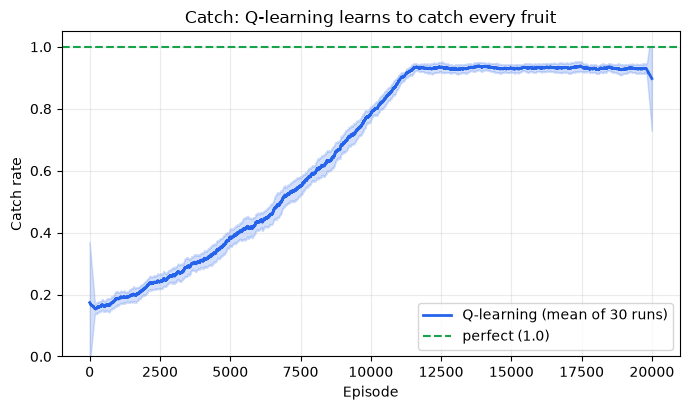

In [4]:
import matplotlib.pyplot as plt
def ma(x, k=400):
    pad = np.concatenate([np.full(k//2, x[0]), x, np.full(k//2, x[-1])])
    return np.convolve(pad, np.ones(k)/k, mode="valid")[:len(x)]
EP = 20000; x = np.arange(1, EP+1)
R = np.stack([ma(train(seed=i, episodes=EP)[1]) for i in range(30)])
m, s = R.mean(0), R.std(0)
plt.figure(figsize=(7, 4.2))
plt.plot(x, m, color="#2563eb", lw=2, label="Q-learning (mean of 30 runs)")
plt.fill_between(x, np.clip(m-s,0,1), np.clip(m+s,0,1), color="#2563eb", alpha=0.2)
plt.axhline(1.0, color="#16a34a", ls="--", label="perfect (1.0)")
plt.ylim(0, 1.05); plt.xlabel("Episode"); plt.ylabel("Catch rate")
plt.title("Catch: Q-learning learns to catch every fruit"); plt.legend(loc="lower right")
plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

## 5. Watch the trained agent play (rendered with pygame)

saved catch.gif


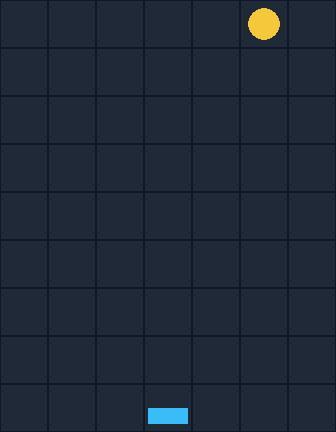

In [5]:
try:
    import imageio.v2 as imageio
    e = CatchEnv(render_mode="rgb_array")
    frames = []
    for sd in [3, 11, 20]:
        s, _ = e.reset(seed=sd); frames.append(e.render()); done = False
        while not done:
            s, r, term, trunc, _ = e.step(int(np.argmax(Q[s]))); done = term or trunc
            frames.append(e.render())
    imageio.mimsave("catch.gif", frames, duration=0.18, loop=0)
    print("saved catch.gif")
    from IPython.display import Image, display
    display(Image(filename="catch.gif"))
except Exception as ex:
    print("rendering needs pygame + imageio:", ex)

## Assignment 16

Build **your own** pygame game as a Gymnasium environment (discrete, `Discrete(n)` observation), train this same Q-learning agent, and run the experiments: a learning curve (mean +/- std), a parameter study, the greedy-policy result, and a video of the trained agent. Copy the `CatchEnv` class above as your template, change the game logic, the state encoding, and the `render()` drawing; the training code stays the same.